# Assignment 3: The "Multimodal Sentiment Engine" Challenge

**Total Marks:** 20 | **Deadline:** 7:00 PM, 22nd March, 2026 | 
**Submission:** A zip file of the folder containing this notebook, and the csv/image files you will create.


---

## Setup

Run the cell below **once** to install all required packages and download NLTK data.

In [27]:
!pip install -r requirements.txt -q

import nltk
for pkg in ["wordnet", "averaged_perceptron_tagger_eng", "punkt_tab", "omw-1.4"]:
    nltk.download(pkg, quiet=True)
print("Setup complete!")

Setup complete!


In [28]:
import os, re, json, time, random, warnings
from collections import Counter
from itertools import combinations
from deep_translator import GoogleTranslator
import time

from dotenv import load_dotenv
load_dotenv()

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk import pos_tag

warnings.filterwarnings("ignore")

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"
LLM_MODEL = "google/gemini-2.0-flash-001"

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Sentiment-bearing words to preserve during augmentation
PRESERVE_WORDS = {
    "amazing", "terrible", "awful", "excellent", "wonderful", "horrible",
    "great", "bad", "good", "worst", "best", "love", "hate", "boring",
    "fantastic", "brilliant", "pathetic", "outstanding", "dreadful",
    "superb", "mediocre",
}
print("Imports loaded. API key present:", bool(OPENROUTER_API_KEY))

Imports loaded. API key present: True


## Task 1: Data Consolidation & Classical Augmentation (5 Marks)

**Steps:**
1. Load all three CSVs and merge them
2. Train a baseline Logistic Regression on `gold_standard_100.csv` (TF-IDF features)
3. Filter `llm_labels_150.csv` -- keep only reviews where baseline confidence ≥ 0.65 AND agrees with LLM label
4. Deduplicate by review text $\rightarrow$ save `consolidated_base.csv`
5. Identify minority class, apply 2 augmentation methods (Synonym Replacement, Back Translation)
6. Quality filter augmented samples (Jaccard similarity)
7. Save `augmented_classical.csv` and `class_distribution.png`

Gold: 100, Weak: 220, LLM: 150
Filtered LLM labels: 27 out of 150 retained.
Consolidated base dataset size: 328
Class Distribution:
label
Negative    151
Neutral     115
Positive     62
Name: count, dtype: int64
Identified Minority Class: **Positive**


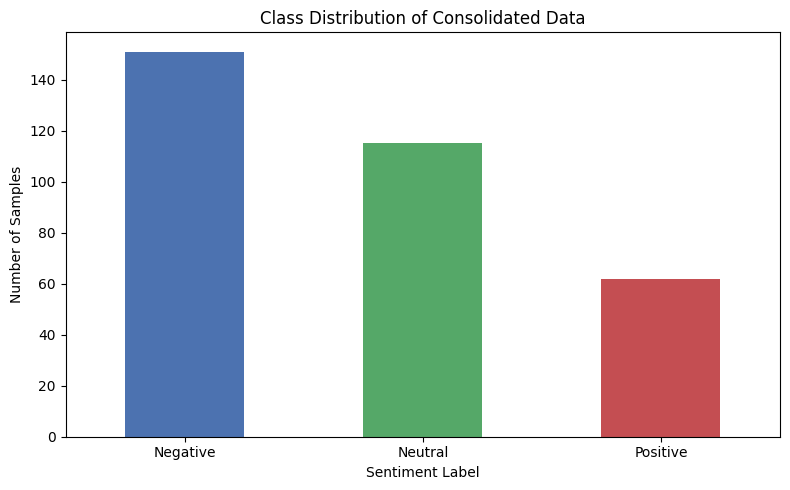

In [29]:
gold = pd.read_csv("gold_standard_100.csv")
weak = pd.read_csv("weak_labels_200.csv")
llm  = pd.read_csv("llm_labels_150.csv")
print(f"Gold: {len(gold)}, Weak: {len(weak)}, LLM: {len(llm)}")

def train_baseline_model(train_df, text_col="review", label_col="label"):
    """Returns (vectorizer, classifier) trained on the given dataframe."""
    vec = TfidfVectorizer(max_features=5000, stop_words="english")
    X = vec.fit_transform(train_df[text_col])
    clf = LogisticRegression(max_iter=1000, class_weight="balanced")
    clf.fit(X, train_df[label_col])
    return vec, clf

vec, clf = train_baseline_model(gold)

# 1c. Filter LLM labels by confidence 
# Predict on llm reviews, keep where confidence >= 0.65 AND prediction matches LLM label
X_llm = vec.transform(llm["review"])
llm_preds = clf.predict(X_llm)
# Get maximum probability for each prediction as the confidence score
llm_probs = clf.predict_proba(X_llm).max(axis=1) 
valid_llm_mask = (llm_probs >= 0.65) & (llm_preds == llm["label"])
filtered_llm = llm[valid_llm_mask].copy()
print(f"Filtered LLM labels: {len(filtered_llm)} out of {len(llm)} retained.")

# 1d. Merge & deduplicate  
# Combine gold + weak + filtered_llm, drop_duplicates on "review"
consolidated_base = pd.concat([gold, weak, filtered_llm], ignore_index=True)
consolidated_base = consolidated_base.drop_duplicates(subset=["review"])

# Save as consolidated_base.csv
consolidated_base.to_csv("consolidated_base.csv", index=False)
print(f"Consolidated base dataset size: {len(consolidated_base)}")

# 1e. Class distribution analysis 
# Count per class, identify minority, plot and save class_distribution.png
class_counts = consolidated_base["label"].value_counts()
minority_class = class_counts.idxmin()

print(f"Class Distribution:\n{class_counts}")
print(f"Identified Minority Class: **{minority_class}**")

# Plotting the graphs
plt.figure(figsize=(8, 5))
class_counts.plot(kind="bar", color=["#4C72B0", "#55A868", "#C44E52"])
plt.title("Class Distribution of Consolidated Data")
plt.xlabel("Sentiment Label")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("class_distribution.png")
plt.show()

In [ ]:
# 1f. Augmentation functions
def get_wordnet_pos(treebank_tag):
    """Map NLTK POS tags to WordNet POS tags for accurate synonym retrieval."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def synonym_replacement(text, replace_frac=0.15):
    """Replace 15-20% of words with WordNet synonyms. Preserve sentiment-bearing words."""
    words = word_tokenize(text)
    tagged_words = pos_tag(words)
    
    # Identify indices of words we are allowed to replace
    eligible_indices = [
        i for i, (word, tag) in enumerate(tagged_words)
        if word.lower() not in PRESERVE_WORDS and word.isalnum()
    ]
    
    # Calculate how many words to replace
    num_replace = max(1, int(len(words) * replace_frac))
    if not eligible_indices:
        return text # Return original if no words can be replaced
        
    replace_indices = random.sample(eligible_indices, min(num_replace, len(eligible_indices)))
    new_words = words.copy()
    
    for idx in replace_indices:
        word, tag = tagged_words[idx]
        wn_pos = get_wordnet_pos(tag)
        
        synonyms = set()
        for syn in wordnet.synsets(word, pos=wn_pos):
            for lemma in syn.lemmas():
                syn_word = lemma.name().replace('_', ' ')
                if syn_word.lower() != word.lower():
                    synonyms.add(syn_word)
                    
        if synonyms:
            new_words[idx] = random.choice(list(synonyms))
            
    return " ".join(new_words)

def back_translate(text, src="en", mid="hi"):
    """Translate English -> Hindi -> English using deep-translator GoogleTranslator."""
    try:
        # Forward translation
        to_hi = GoogleTranslator(source=src, target=mid).translate(text)
        time.sleep(0.5) # Rate limit sleep
        
        # Back translation
        back_to_en = GoogleTranslator(source=mid, target=src).translate(to_hi)
        time.sleep(0.5) # Rate limit sleep
        
        return back_to_en
    except Exception as e:
        print(f"Translation error: {e}")
        return text

def quality_filter(original, augmented):
    """Return True if augmented text passes Jaccard similarity (0.30–0.95)."""
    set_orig = set(word_tokenize(original.lower()))
    set_aug = set(word_tokenize(augmented.lower()))
    
    intersection = len(set_orig.intersection(set_aug))
    union = len(set_orig.union(set_aug))
    
    if union == 0: 
        return False
        
    jaccard = intersection / union
    return 0.30 <= jaccard <= 0.95

# 1g. Apply augmentation to minority class

print("Starting classical augmentation...")
minority_df = consolidated_base[consolidated_base["label"] == minority_class]
augmented_data = []

for _, row in minority_df.iterrows():
    orig_review = row["review"]
    label = row["label"]
    
    # Method A: Synonym Replacement
    aug_syn = synonym_replacement(orig_review)
    if quality_filter(orig_review, aug_syn):
        augmented_data.append({"review": aug_syn, "label": label, "source": "synonym_replacement"})
        
    # Method B: Back Translation
    aug_bt = back_translate(orig_review)
    if quality_filter(orig_review, aug_bt):
        augmented_data.append({"review": aug_bt, "label": label, "source": "back_translation"})

augmented_classical = pd.DataFrame(augmented_data)
augmented_classical.to_csv("augmented_classical.csv", index=False)

print(f"Successfully generated {len(augmented_classical)} valid augmented samples for the '{minority_class}' class.")

Starting classical augmentation...
Successfully generated 119 valid augmented samples for the 'Positive' class.


## Task 2: LLM-Based Synthetic Review Generation (5 Marks)

**Steps:**
1. Design a few-shot prompt with 3-4 gold-standard examples
2. Use OpenRouter API (via `openai` package) to generate 300 synthetic reviews in batches of 20
3. Calculate diversity metrics: Self-BLEU per class
4. Run sentiment consistency check with baseline model $\rightarrow$ flag mismatches
5. Save `llm_generated_300.csv`, `llm_generated_flagged.csv`, `prompt_template.txt`, `diversity_report.txt`

In [ ]:
import json
import time
import re
import numpy as np
import pandas as pd
from openai import OpenAI
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.tokenize import word_tokenize

client = OpenAI(base_url=OPENROUTER_BASE_URL, api_key=OPENROUTER_API_KEY)

# --- 2a. Design your few-shot prompt ---
# We use placeholders for target_sentiment and batch_size to dynamically generate batches.
PROMPT_TEMPLATE = """You are an expert data annotator and movie review generator.
Your task is to generate {batch_size} highly diverse, realistic movie reviews with a strictly '{target_sentiment}' sentiment.

Here are examples of the quality and style we expect:
- "An absolute masterpiece. The acting was phenomenal and the plot twists were genuinely unexpected." (Sentiment: positive)
- "The pacing was incredibly slow, but the stunning cinematography kept me watching until the end." (Sentiment: neutral)
- "Terrible script and wooden acting. A complete waste of time and money." (Sentiment: negative)
- "I really wanted to love this, but the character development felt rushed and the climax fell flat." (Sentiment: negative)

REQUIREMENTS:
1. Ensure high linguistic diversity (vary sentence structures, vocabulary, and lengths).
2. Do NOT use the exact phrasing from the examples above.
3. Output strictly a JSON array of dictionaries with no surrounding text, no markdown blocks, and no explanations.

Expected JSON schema:
[
  {"review": "...", "sentiment": "{target_sentiment}", "movie": "..."}
]
"""

# Save prompt to file
with open("prompt_template.txt", "w", encoding="utf-8") as f:
    f.write(PROMPT_TEMPLATE)


def extract_json_array(text):
    """Helper to robustly extract a JSON array from LLM output, ignoring markdown."""
    match = re.search(r'\[.*\]', text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group(0))
        except json.JSONDecodeError:
            pass
    return []

# --- 2b. Generate reviews in batches ---
print("Starting LLM generation...")
TARGET_DISTRIBUTION = {"positive": 150, "negative": 100, "neutral": 50}
generated_data = []

for sentiment, target_count in TARGET_DISTRIBUTION.items():
    current_count = 0
    print(f"\nGenerating {target_count} {sentiment} reviews...")
    
    while current_count < target_count:
        batch_size = min(20, target_count - current_count)
        prompt = PROMPT_TEMPLATE.format(batch_size=batch_size, target_sentiment=sentiment)
        
        try:
            response = client.chat.completions.create(
                model=LLM_MODEL,
                messages=[{"role": "user", "content": prompt}],
                temperature=0.8, # Slightly higher temperature for diversity
            )
            
            raw_text = response.choices[0].message.content
            batch_data = extract_json_array(raw_text)
            
            if not batch_data:
                print("Failed to parse JSON, retrying batch...")
                time.sleep(2)
                continue
                
            # Filter out any that didn't follow the sentiment instruction
            valid_batch = [item for item in batch_data if item.get("sentiment", "").lower() == sentiment]
            generated_data.extend(valid_batch)
            current_count += len(valid_batch)
            print(f"  Generated {current_count}/{target_count} {sentiment} reviews.")
            
            time.sleep(1.5) # Rate limit protection
            
        except Exception as e:
            print(f"API Error: {e}. Retrying in 5 seconds...")
            time.sleep(5)

# Convert to DataFrame
df_generated = pd.DataFrame(generated_data)
# Ensure consistent label naming (matching Task 1)
df_generated.rename(columns={"sentiment": "label"}, inplace=True)


# --- 2c. Diversity metrics (Self-BLEU) ---
print("\nCalculating Self-BLEU diversity scores...")
smoother = SmoothingFunction().method1
diversity_results = {}

for label in df_generated["label"].unique():
    class_reviews = df_generated[df_generated["label"] == label]["review"].tolist()
    tokenized_reviews = [word_tokenize(text.lower()) for text in class_reviews]
    
    bleu_scores = []
    # Compare each sentence against all other sentences in the same class
    for i, tokens in enumerate(tokenized_reviews):
        references = tokenized_reviews[:i] + tokenized_reviews[i+1:]
        # Calculate BLEU (lower is more diverse)
        score = sentence_bleu(references, tokens, smoothing_function=smoother)
        bleu_scores.append(score)
    
    avg_bleu = np.mean(bleu_scores)
    diversity_results[label] = avg_bleu
    print(f"  {label.capitalize()} Self-BLEU: {avg_bleu:.4f} (Lower = more diverse)")

# Save diversity report
with open("diversity_report.txt", "w", encoding="utf-8") as f:
    f.write("Self-BLEU Diversity Report (Lower scores indicate higher diversity)\n")
    f.write("="*65 + "\n")
    for label, score in diversity_results.items():
        f.write(f"Class: {label.capitalize():<10} | Average Self-BLEU: {score:.4f}\n")


# --- 2d. Sentiment consistency check ---
print("\nRunning consistency check against Task 1 baseline model...")
# Transform texts using the vectorizer from Task 1
X_gen = vec.transform(df_generated["review"])

# Predict using the classifier from Task 1
baseline_preds = clf.predict(X_gen)
df_generated["baseline_pred"] = baseline_preds

# Flag mismatches (where LLM generation intent != Baseline prediction)
df_generated["is_mismatch"] = df_generated["label"] != df_generated["baseline_pred"]
df_flagged = df_generated[df_generated["is_mismatch"]].copy()

print(f"Found {len(df_flagged)} mismatched reviews out of {len(df_generated)}.")

# Remove flagged data from the clean generated set
df_clean_generated = df_generated[~df_generated["is_mismatch"]].drop(columns=["baseline_pred", "is_mismatch"])


# --- 2e. Save outputs ---
df_clean_generated.to_csv("llm_generated_300.csv", index=False)
df_flagged.to_csv("llm_generated_flagged.csv", index=False)

print("Task 2 complete. Files saved: 'llm_generated_300.csv', 'llm_generated_flagged.csv', 'prompt_template.txt', 'diversity_report.txt'.")

## Task 3: Multilingual Sentiment Translation (4 Marks)

**Steps:**
1. Sample 100 reviews (40 Pos, 40 Neg, 20 Neu), prioritize shorter reviews
2. Translate English $\rightarrow$ Hindi using `deep-translator` (`GoogleTranslator`)
3. Back-translate Hindi $\rightarrow$ English, compute BLEU score (threshold ≥ 0.3)
4. Check sentiment preservation on back-translated text
5. Manually verify 5 random samples
6. Save `bilingual_reviews.csv` with `bleu_score` and `quality_flag` columns

In [27]:
from deep_translator import GoogleTranslator
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

#  3a. Strategic sampling 
# TODO: From consolidated_base, sample 100 reviews (40 Pos, 40 Neg, 20 Neu)
# Prioritize shorter reviews (sort by length, take shortest)


#  3b. Translation pipeline 
# TODO: Translate each review English $\rightarrow$ Hindi using GoogleTranslator(source='en', target='hi')
# Add time.sleep(0.5) between calls to avoid rate limits


#  3c. Back-translation & BLEU 
# TODO: Translate Hindi $\rightarrow$ English
# Compute sentence BLEU between original and back-translated
# quality_flag = "PASS" if BLEU >= 0.3, else "FAIL"


#  3d. Sentiment preservation check 
# TODO: Predict sentiment on back-translated text, compare with original label
    

#  3e. Manual verification 
# TODO: Print 5 random samples for inspection


#  3f. Save 
# TODO: Save bilingual_reviews.csv with columns:
# review, label, hindi, back_translated, bleu_score, quality_flag

## Task 4: Multimodal Audio Generation (4 Marks)

**Steps:**
1. Select 30 reviews (10 per class) of varying lengths
2. Use `gTTS` to generate audio (`tld="com"`), convert mp3$\rightarrow$wav via `librosa`+`soundfile`
3. Extract audio features with `librosa`: duration, spectral centroid, zero crossing rate, MFCCs
4. Use `openai-whisper` (tiny model) to transcribe audio back to text, compute WER
5. Save `audio_samples/` folder, `audio_features.csv`, `audio_validation.csv`

In [28]:
from gtts import gTTS
import librosa, soundfile as sf

#  4a. Select 30 reviews (10 per class) 
# TODO: Sample from consolidated_base, mix short and long reviews


#  4b. TTS generation 
os.makedirs("audio_samples", exist_ok=True)

# TODO: For each review, generate audio with gTTS (tld="com")
# Save as mp3, then load with librosa and re-save as .wav via soundfile


#  4c. Audio feature extraction 
# TODO: For each wav, extract with librosa:
#   - duration (librosa.get_duration)
#   - spectral centroid (librosa.feature.spectral_centroid)
#   - zero crossing rate (librosa.feature.zero_crossing_rate)
#   - MFCCs (librosa.feature.mfcc, n_mfcc=13, take mean)
# Save audio_features.csv


#  4d. Whisper round-trip validation 
import whisper

_whisper_model = whisper.load_model("tiny")

# TODO: Transcribe each wav with Whisper
# Compute WER (word-level Levenshtein distance / reference word count)
# Flag samples with WER > 0.25
# Save audio_validation.csv

100%|█████████████████████████████████████| 72.1M/72.1M [00:03<00:00, 24.5MiB/s]


## Task 5: Final Dataset Assembly & Model Evaluation (2 Marks)

**Steps:**
1. Merge all datasets: `consolidated_base.csv` + `augmented_classical.csv` + `llm_generated_300.csv` (excluding flagged) + English text from `bilingual_reviews.csv`
2. Deduplicate $\rightarrow$ save `final_augmented_dataset.csv`
3. Use `BlackBoxEvaluator` from `evaluator.py` to compare baseline vs augmented accuracy

In [29]:
from evaluator import BlackBoxEvaluator

#  5a. Assemble final dataset 
# TODO: Load consolidated_base, augmented_classical, llm_generated_300, bilingual_reviews
# Exclude flagged LLM reviews
# Merge all, deduplicate on "review" column
# Save final_augmented_dataset.csv


#  5b. Black-Box Evaluation 
evaluator = BlackBoxEvaluator()
test_df = pd.read_csv("gold_standard_100.csv")

# Baseline evaluation (small dataset only)
# TODO: baseline_acc = evaluator.run_evaluation(consolidated_base, test_df)

# Augmented evaluation (full dataset)
# TODO: augmented_acc = evaluator.run_evaluation(final_augmented, test_df)

# Print comparison
# print(f"Baseline accuracy:  {baseline_acc:.2%}")
# print(f"Augmented accuracy: {augmented_acc:.2%}")
# print(f"Improvement:        {augmented_acc - baseline_acc:+.2%}")

KeyboardInterrupt: 